# Customer Acquisition Cost Analysis

This project uses the Bank Marketing dataset to estimate CAC by contact channel and prepare data for an Excel Solver optimization model.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/bank.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Step 1: Understand the dataset

The dataset contains customer level records from bank marketing campaigns. The target column `y` shows whether a customer subscribed or not.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [26]:
# Create acquisition flag
df["acquired"] = df["y"].map({"yes": 1, "no": 0})

# Assign channel cost assumptions
cost_map = {
    "cellular": 3.0,
    "telephone": 4.5,
    "unknown": 1.5
}

df["cost_per_contact"] = df["contact"].map(cost_map)

# Estimate acquisition cost
df["estimated_cost"] = df["campaign"] * df["cost_per_contact"]

df[["contact", "campaign", "cost_per_contact", "estimated_cost", "acquired"]].head()

,contact,campaign,cost_per_contact,estimated_cost,acquired
0,unknown,1,1.5,1.5,0
1,unknown,1,1.5,1.5,0
2,unknown,1,1.5,1.5,0
3,unknown,1,1.5,1.5,0
4,unknown,1,1.5,1.5,0


## Step 2: Build channel level CAC summary

Now that each customer record has an estimated acquisition cost, the next step is to summarize performance by contact channel.

This helps answer:
- which channel converts best
- which channel has the lowest estimated CAC
- which channel brings in more customers per budget spent

In [27]:
# Channel level summary
channel_summary = df.groupby("contact").agg(
    total_records=("acquired", "size"),
    customers_acquired=("acquired", "sum"),
    total_contacts=("campaign", "sum"),
    avg_contacts=("campaign", "mean"),
    total_estimated_cost=("estimated_cost", "sum"),
    avg_duration=("duration", "mean")
).reset_index()

# Create performance metrics
channel_summary["conversion_rate"] = (
    channel_summary["customers_acquired"] / channel_summary["total_records"]
)

channel_summary["estimated_cac"] = (
    channel_summary["total_estimated_cost"] / channel_summary["customers_acquired"]
)

channel_summary["customers_per_1000"] = (
    channel_summary["customers_acquired"] / (channel_summary["total_estimated_cost"] / 1000)
)

channel_summary = channel_summary.sort_values("estimated_cac")
channel_summary

,contact,total_records,customers_acquired,total_contacts,avg_contacts,total_estimated_cost,avg_duration,conversion_rate,estimated_cac,customers_per_1000
0,cellular,29285,4369,78780,2.690114,236340.0,263.013966,0.149189,54.094759,18.486079
2,unknown,13020,530,36293,2.787481,54439.5,252.340476,0.040707,102.716038,9.735578
1,telephone,2906,390,9883,3.400895,44473.5,235.366139,0.134205,114.034615,8.769267


In [28]:
print(channel_summary)

     contact  total_records  customers_acquired  total_contacts  avg_contacts  \
0   cellular          29285                4369           78780      2.690114   
2    unknown          13020                 530           36293      2.787481   
1  telephone           2906                 390            9883      3.400895   

   total_estimated_cost  avg_duration  conversion_rate  estimated_cac  \
0              236340.0    263.013966         0.149189      54.094759   
2               54439.5    252.340476         0.040707     102.716038   
1               44473.5    235.366139         0.134205     114.034615   

   customers_per_1000  
0           18.486079  
2            9.735578  
1            8.769267  


## Step 3: Visualize channel performance

The charts below compare channels using three key business metrics:
- conversion rate
- estimated CAC
- customers acquired

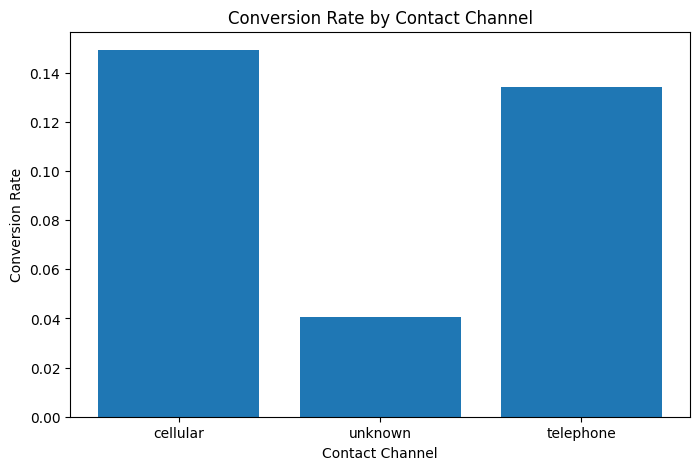

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(channel_summary["contact"], channel_summary["conversion_rate"])
plt.title("Conversion Rate by Contact Channel")
plt.xlabel("Contact Channel")
plt.ylabel("Conversion Rate")
plt.show()

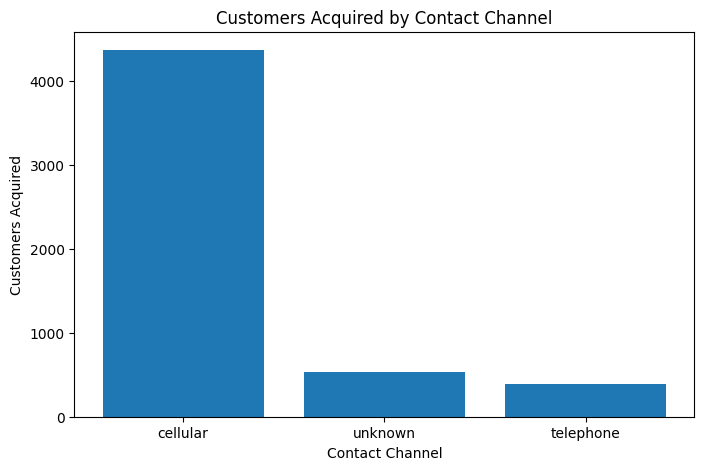

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(channel_summary["contact"], channel_summary["customers_acquired"])
plt.title("Customers Acquired by Contact Channel")
plt.xlabel("Contact Channel")
plt.ylabel("Customers Acquired")
plt.show()

## Step 4: Prepare a Solver ready budget allocation table

The channel summary shows past performance. To use Excel Solver, we need a smaller decision table that translates channel efficiency into a budget allocation model.

This table will be used to decide how much budget should be assigned to each contact channel in order to either minimize CAC or maximize acquired customers.

In [ ]:
solver_table = channel_summary[["contact", "estimated_cac", "conversion_rate", "customers_per_1000"]].copy()

solver_table["max_budget"] = [220000, 35253, 80000]
solver_table["min_budget"] = [150000, 15000, 40000]
solver_table["budget_allocation"] = [2200000, 35253, 80000]

solver_table["expected_customers"] = (
    solver_table["budget_allocation"] / solver_table["estimated_cac"]
)

solver_table["expected_cost_check"] = solver_table["budget_allocation"]

solver_table

,contact,estimated_cac,conversion_rate,customers_per_1000,max_budget,min_budget,budget_allocation,expected_customers,expected_cost_check
0,cellular,54.094759,0.149189,18.486079,2200000,150000,2200000,40669.374630,2200000
2,unknown,102.716038,0.040707,9.735578,80000,15000,80000,778.846242,80000
1,telephone,114.034615,0.134205,8.769267,35253,40000,35253,309.142973,35253


In [32]:
channel_summary.to_csv("data/channel_summary.csv", index=False)
solver_table.to_csv("data/solver_table.csv", index=False)

print("Files exported successfully.")

Files exported successfully.


In [33]:
df["estimated_cost"].sum()

np.float64(335253.0)

## Business Questions

## Which channel has the highest conversion rate?

In [34]:
channel_summary[["contact", "conversion_rate"]].sort_values("conversion_rate", ascending=False)

,contact,conversion_rate
0,cellular,0.149189
1,telephone,0.134205
2,unknown,0.040707


Based on the Python channel summary, the **cellular** channel has the highest conversion rate at **14.92%**. This means it converted the largest share of contacted customers into successful acquisitions.

## Which channel has the lowest estimated CAC?



In [35]:
channel_summary["estimated_cac"] = (
    channel_summary["total_estimated_cost"] / channel_summary["customers_acquired"]
)
print(channel_summary)

     contact  total_records  customers_acquired  total_contacts  avg_contacts  \
0   cellular          29285                4369           78780      2.690114   
2    unknown          13020                 530           36293      2.787481   
1  telephone           2906                 390            9883      3.400895   

   total_estimated_cost  avg_duration  conversion_rate  estimated_cac  \
0              236340.0    263.013966         0.149189      54.094759   
2               54439.5    252.340476         0.040707     102.716038   
1               44473.5    235.366139         0.134205     114.034615   

   customers_per_1000  
0           18.486079  
2            9.735578  
1            8.769267  


The **cellular** channel has the lowest estimated CAC at **54.09**, meaning it is the most cost efficient channel for acquiring customers under the current assumptions.

In [36]:
print(channel_summary[["contact", "conversion_rate", "estimated_cac", "customers_per_1000"]])

     contact  conversion_rate  estimated_cac  customers_per_1000
0   cellular         0.149189      54.094759           18.486079
2    unknown         0.040707     102.716038            9.735578
1  telephone         0.134205     114.034615            8.769267
